===== FIRST 5 ROWS =====
   car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          front       88.6  ...         130   
1  convertible        rwd          front       88.6  ...         130   
2    hatchback        rwd          front       94.5  ...         152   
3        sedan        fwd          front       99.8  ...         109   
4        sedan        4wd          front       99.4  ...         136   

   fuelsystem  boreratio  stroke compressionratio horse

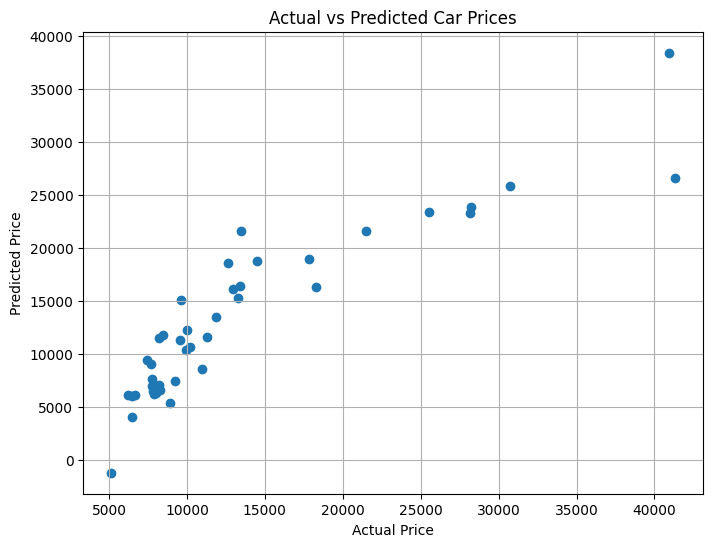

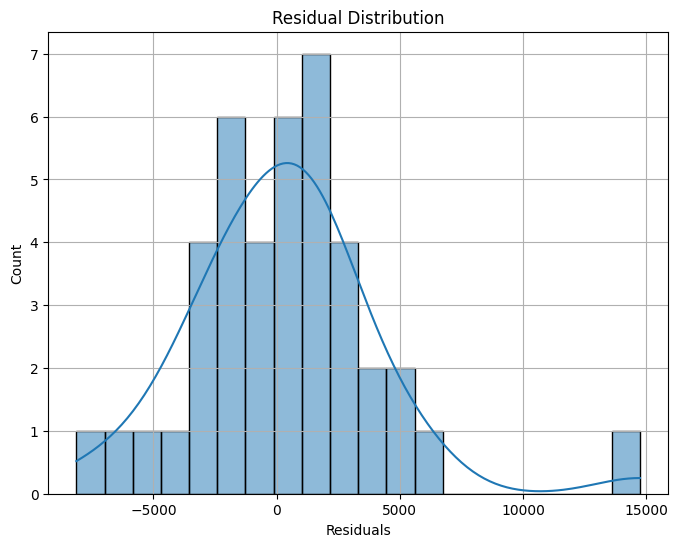


===== NEW CAR PREDICTION =====
Predicted Car Price: $13,200.35


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

df = pd.read_csv('/CarPrice_Assignment.csv')

print("===== FIRST 5 ROWS =====")
print(df.head())

print("\n===== DATASET SHAPE =====")
print(df.shape)

print("\n===== COLUMN NAMES =====")
print(df.columns.tolist())

print("\n===== DATA TYPES =====")
print(df.dtypes)

print("\n===== MISSING VALUES =====")
print(df.isnull().sum())


features = [
    'enginesize',
    'horsepower',
    'curbweight',
    'wheelbase',
    'carlength',
    'carwidth',
    'citympg',
    'highwaympg'
]

X = df[features]
y = df['price']


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\n===== TRAIN TEST SHAPES =====")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


model = LinearRegression()
model.fit(X_train, y_train)

print("\n===== MODEL TRAINED SUCCESSFULLY =====")


coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
})

print("\n===== FEATURE COEFFICIENTS =====")
print(coef_df)

y_pred = model.predict(X_test)


r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("\n===== MODEL EVALUATION =====")
print(f"R2 Score : {r2:.4f}")
print(f"MAE      : {mae:.2f}")
print(f"MSE      : {mse:.2f}")
print(f"RMSE     : {rmse:.2f}")


comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': np.round(y_pred, 2)
})

print("\n===== ACTUAL VS PREDICTED =====")
print(comparison.head(10))


plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Car Prices')
plt.grid(True)
plt.show()


residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
sns.histplot(residuals, bins=20, kde=True)
plt.title('Residual Distribution')
plt.xlabel('Residuals')
plt.grid(True)
plt.show()


new_car = pd.DataFrame({
    'enginesize': [130],
    'horsepower': [111],
    'curbweight': [2500],
    'wheelbase': [95],
    'carlength': [170],
    'carwidth': [65],
    'citympg': [25],
    'highwaympg': [32]
})

predicted_price = model.predict(new_car)

print("\n===== NEW CAR PREDICTION =====")
print(f"Predicted Car Price: ${predicted_price[0]:,.2f}")